In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [3]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler 
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold, train_test_split, GridSearchCV
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.ticker as ticker
from scipy.stats import sem
from scipy.signal import savgol_filter

In [5]:
# Adjust the path to match your Box sync folder location
box_path = os.path.expanduser(r"C:\Users\HIALAB\Box\Human_AGV_project\ISU_Modeling\Code")

In [7]:
save_dir = "../Images/"

In [9]:
study_data_by_sec = pd.read_csv(os.path.join(box_path, 'study_data_by_sec_processed.csv'))
study_data_by_sec

,User_X,User_Y,User_Z,User_Pitch,User_Yaw,User_Roll,U_X,U_Y,U_Z,GazeOrigin_X,...,PID,DRate,User_Relative_Speed,AGV_Relative_Speed,AGV_User_distance,EyeTarget,Angle_to_AGV,AGV_in_FOV,Angle_to_Destination,Destination_in_FOV
0,5051.235,8610.830,-209.725,-21.168361,-92.384752,0.290698,60.493000,-108.133857,156.034571,4990.742143,...,1,High,0.0,84.241150,6811.521389,BP_Affordance_C_0,203.080077,False,112.737321,False
1,5051.235,8610.830,-209.725,-21.168361,-92.384752,0.290698,60.493000,-108.133857,156.034571,4990.742143,...,1,High,0.0,84.241150,6811.521389,BP_Affordance_C_0,203.080077,False,112.737321,False
2,5051.235,8610.830,-209.725,-21.168361,-92.384752,0.290698,60.493000,-108.133857,156.034571,4990.742143,...,1,High,0.0,84.241150,6811.521389,BP_Affordance_C_0,203.080077,False,112.737321,False
3,5051.235,8610.830,-209.725,-21.168361,-92.384752,0.290698,60.493000,-108.133857,156.034571,4990.742143,...,1,High,0.0,84.241150,6811.521389,BP_Affordance_C_0,203.080077,False,112.737321,False
4,5051.235,8610.830,-209.725,-21.168361,-92.384752,0.290698,60.493000,-108.133857,156.034571,4990.742143,...,1,High,0.0,84.241150,6811.521389,BP_Affordance_C_0,203.080077,False,112.737321,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7376308,4814.045,8544.847,-209.725,7.603790,-93.517554,0.112428,-57.683000,-37.738571,162.621143,4871.727857,...,46,Low,0.0,0.313207,3573.126479,BP_CheckPoint3,324.469750,False,90.000000,True
7376309,4814.045,8544.847,-209.725,9.593631,-101.241813,-2.028508,-59.239429,-37.026714,162.851143,4873.284286,...,46,Low,0.0,0.299045,3572.918260,BP_CheckPoint3,324.691134,False,90.000000,True
7376310,4814.045,8544.847,-209.725,10.106079,-86.682990,-1.234411,-57.745714,-36.808571,162.943429,4871.790429,...,46,Low,0.0,0.309687,3572.707442,BP_CheckPoint3,353.788991,False,90.000000,True
7376311,4814.045,8544.847,-209.725,10.802710,-103.167978,-1.137901,-59.808714,-36.247000,163.049286,4873.853429,...,46,Low,0.0,0.313157,3572.496169,BP_CheckPoint3,335.098915,False,90.000000,True


In [10]:
null_counts = study_data_by_sec.isnull().sum()
null_counts

User_X                  0
User_Y                  0
User_Z                  0
User_Pitch              0
User_Yaw                0
User_Roll               0
U_X                     0
U_Y                     0
U_Z                     0
GazeOrigin_X            0
GazeOrigin_Y            0
GazeOrigin_Z            0
GazeDirection_X         0
GazeDirection_Y         0
GazeDirection_Z         0
Confidence              0
Gaze_on_AGV             0
AGV_X                   0
AGV_Y                   0
AGV_Z                   0
AGV_Pitch               0
AGV_Yaw                 0
AGV_Roll                0
AGV_spd                 0
Timestamp               0
AGVname                 0
PID                     0
DRate                   0
User_Relative_Speed     0
AGV_Relative_Speed      0
AGV_User_distance       0
EyeTarget               0
Angle_to_AGV            0
AGV_in_FOV              0
Angle_to_Destination    0
Destination_in_FOV      0
dtype: int64

In [11]:
data = pd.read_csv(os.path.join(box_path, 'Per_Interaction_Data_Merged.csv'))
data

,PID,DRate,date,hr,min,s,AGVname,StartTime,EndTime,GazeDuration,...,AGV_Path_Complexity,Trust_before,Cross_First_Flag,User_Relative_Speed,AGV_Relative_Speed,Frechet_Distance_3,Frechet_Distance_5,Frechet_Distance_7,Frechet_Distance_10,Cross_First
0,1,High,2024-5-3,14,28,53,1,1900-01-01 15:02:48,1900-01-01 15:03:38,219,...,Straight,4.9,True,74.580213,100.420508,730.13,1188.92,1532.83,1771.61,N\A
1,1,High,2024-5-3,14,28,53,2,1900-01-01 15:03:47,1900-01-01 15:04:29,0,...,Complex,10.0,True,47.888087,232.345812,14.56,97.05,108.21,247.34,N\A
2,1,High,2024-5-3,14,28,53,3,1900-01-01 15:04:37,1900-01-01 15:05:34,268,...,Complex,10.0,True,63.130599,120.176130,282.09,482.54,821.32,1067.08,User
3,1,High,2024-5-3,14,28,53,4,1900-01-01 15:05:46,1900-01-01 15:06:37,779,...,Complex,10.0,True,43.571998,263.284416,421.34,544.15,577.55,610.84,User
4,1,High,2024-5-3,14,28,53,5,1900-01-01 15:06:41,1900-01-01 15:07:44,868,...,Complex,7.0,True,93.720008,91.614207,486.65,852.85,1225.51,1722.14,N\A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1317,46,Low,2024-8-26,16,55,4,12,1900-01-01 17:07:02,1900-01-01 17:08:21,595,...,Complex,9.0,NaN,77.121444,90.961763,224.51,507.80,789.37,1176.65,User
1318,46,Low,2024-8-26,16,55,4,13,1900-01-01 17:08:24,1900-01-01 17:09:05,0,...,Complex,9.0,NaN,54.297007,286.165319,420.27,627.75,714.38,937.14,AGV
1319,46,Low,2024-8-26,16,55,4,14,1900-01-01 17:09:08,1900-01-01 17:09:52,0,...,Straight,10.0,NaN,82.319060,221.787091,408.09,668.13,919.97,1180.07,User
1320,46,Low,2024-8-26,16,55,4,15,1900-01-01 17:09:56,1900-01-01 17:10:31,67,...,Straight,10.0,NaN,65.826092,278.817960,301.57,562.78,774.23,998.19,User


In [12]:
null_counts = data.isnull().sum()
null_counts

PID                        0
DRate                      0
date                       0
hr                         0
min                        0
s                          0
AGVname                    0
StartTime                  0
EndTime                    0
GazeDuration               0
mean_dist                  0
min_dist                   0
max_dist                   0
std_dist                   0
mean_agv_spd               0
min_agv_spd                0
max_agv_spd                0
std_spd                    0
task                       0
Trust                      0
Safe                       0
Comfort                    0
Expect                     0
Age                        0
Gender                     0
Ethnicity                  0
GamingFrequency            0
VRExperience               0
VRHeadsetExperience        0
AGVInteraction             0
PerfectAutomation          0
TrustPropensity            0
AutomationExperience       0
Trust1                     0
Trust2        

In [13]:
data[['AGV_Approaching', 'User_Trajectory', 'AGV_User_Combination']].head()

,AGV_Approaching,User_Trajectory,AGV_User_Combination
0,South,Straight,South - Straight
1,North,Diagonal,North - Diagonal
2,South,Diagonal,South - Diagonal
3,Northeast,Straight,Northeast - Straight
4,Northwest,Straight,Northwest - Straight


In [14]:
data['AGV_Approaching'].unique()

array(['South', 'North', 'Northeast', 'Northwest', 'East', 'Southwest',
       'West', 'Southeast'], dtype=object)

In [15]:
approach_map = {}

grouped = data.groupby('AGV_Approaching')['AGVname'].unique()

for approach, agv_list in grouped.items():
    for agv in agv_list:
        approach_map[agv] = approach

In [16]:
trajectory_map = {}

grouped = data.groupby('User_Trajectory')['AGVname'].unique()

for trajectory, agv_list in grouped.items():
    for agv in agv_list:
        trajectory_map[agv] = trajectory

In [17]:
study_data_by_sec['AGV_Approaching'] = study_data_by_sec['AGVname'].map(approach_map)
study_data_by_sec['User_Trajectory'] = study_data_by_sec['AGVname'].map(trajectory_map)

In [18]:
study_data_by_sec[['AGV_Approaching', 'AGVname', 'User_Trajectory']].iloc[5000:5010]

,AGV_Approaching,AGVname,User_Trajectory
5000,North,2,Diagonal
5001,North,2,Diagonal
5002,North,2,Diagonal
5003,North,2,Diagonal
5004,North,2,Diagonal
5005,North,2,Diagonal
5006,North,2,Diagonal
5007,North,2,Diagonal
5008,North,2,Diagonal
5009,North,2,Diagonal


In [19]:
physio_amp_plot = study_data_by_sec.copy()

physio_amp_plot_high = physio_amp_plot[physio_amp_plot['DRate'] == 'High'].copy()
physio_amp_plot_low = physio_amp_plot[physio_amp_plot['DRate'] == 'Low'].copy()

In [31]:
def add_normalized_time(df, column='Angle_to_AGV', smooth=True, DRate=None, group_col='AGVname'):
    df = df.copy()
    
    if DRate:
        df = df[df['DRate'] == DRate].copy()

    current_max_time = 0
    norm_time_dict = {}
    time_ranges = {}

    clean_records = []

    for group_val in sorted(df[group_col].dropna().unique()):
        group_df = df[df[group_col] == group_val]

        # Get the largest (PID, group_col) group size to scale normalized time
        max_len = group_df.groupby(['PID', group_col]).size().max()

        for (pid, val), sub_group in group_df.groupby(['PID', group_col]):
            data = sub_group.copy()
            y = data[column]

            # --- IQR outlier filtering ---
            Q1, Q3 = y.quantile([0.25, 0.75])
            IQR = Q3 - Q1
            mask = (y >= Q1 - 1.5 * IQR) & (y <= Q3 + 1.5 * IQR)
            data = data[mask]

            # --- Smoothing ---
            if smooth and len(data) >= 11:
                y_clean = data[column].values
                window = min(11, len(data) if len(data) % 2 != 0 else len(data) - 1)
                smoothed = savgol_filter(y_clean, window_length=window, polyorder=2)
                data[column] = smoothed

            # --- Normalized time assignment ---
            count = len(data)
            norm_times = np.linspace(current_max_time + 1, current_max_time + max_len, count, dtype=int)
            norm_time_dict.update(dict(zip(data.index, norm_times)))

            clean_records.append(data)

        time_ranges[group_val] = (current_max_time + 1, current_max_time + max_len)
        current_max_time += max_len

    # Concatenate all cleaned/smoothed data
    df_cleaned = pd.concat(clean_records)
    df_cleaned['Normalized_Time'] = df_cleaned.index.map(norm_time_dict)

    return df_cleaned, time_ranges

In [37]:
def plot_segmented(df, DRate='High', column='Angle_to_AGV', normalize=False, group_col='AGVname', ax=None):
    df = df[df['DRate'] == DRate].copy()

    if ax is None:
        fig, ax = plt.subplots(figsize=(16, 5))

    ax.set_title(f"DRate = {DRate}")
    ax.set_xlabel("Normalized Time")
    ax.set_ylabel(f"{column} (normalized)" if normalize else f"{column} (raw)")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.grid(True)

    # Automatically assign a color to each group value
    unique_groups = sorted(df[group_col].dropna().unique())
    palette = sns.color_palette("tab20", len(unique_groups))
    group_colors = dict(zip(unique_groups, palette))

    for group_value in unique_groups:
        segment_df = df[df[group_col] == group_value].copy()

        if normalize:
            min_val = segment_df[column].min()
            max_val = segment_df[column].max()
            segment_df.loc[:, column] = (segment_df[column] - min_val) / (max_val - min_val + 1e-8)

        grouped = segment_df.groupby('Normalized_Time')[column]
        mean = grouped.mean()
        ci = 1.96 * grouped.sem()

        plot_df = pd.DataFrame({'mean': mean, 'ci': ci}).dropna().reset_index()

        x = plot_df['Normalized_Time'].astype(float).values
        y = plot_df['mean'].astype(float).values
        error = plot_df['ci'].astype(float).values
        color = group_colors[group_value]

        ax.plot(x, y, label=f"{group_col} = {group_value}", color=color)
        ax.fill_between(x, y - error, y + error, color=color, alpha=0.3)

    return ax

### By Approach

In [33]:
df_by_approach_low, _ = add_normalized_time(
    study_data_by_sec,
    column='User_Relative_Speed',
    smooth=True,
    DRate='Low',
    group_col='AGV_Approaching'
)

In [34]:
df_by_approach_low.head()

,User_X,User_Y,User_Z,User_Pitch,User_Yaw,User_Roll,U_X,U_Y,U_Z,GazeOrigin_X,...,AGV_Relative_Speed,AGV_User_distance,EyeTarget,Angle_to_AGV,AGV_in_FOV,Angle_to_Destination,Destination_in_FOV,AGV_Approaching,User_Trajectory,Normalized_Time
108334,13854.68,6230.338,-210.878,-12.396354,-1.760786,-30.168624,70.627286,-102.116143,155.232571,13784.052143,...,0.0,4699.701801,SM_Wall_Divider_01_5m6,313.048683,False,39.863955,True,East,Straight,1
108335,13854.68,6230.338,-210.878,-12.396354,-1.760786,-30.168624,70.627286,-102.116143,155.232571,13784.052143,...,0.0,4699.701801,SM_Wall_Divider_01_5m6,313.048683,False,39.863955,True,East,Straight,3
108336,13854.68,6230.338,-210.878,-12.396354,-1.760786,-30.168624,70.627286,-102.116143,155.232571,13784.052143,...,0.0,4699.701801,SM_Wall_Divider_01_5m6,313.048683,False,39.863955,True,East,Straight,5
108337,13854.68,6230.338,-210.878,-12.396354,-1.760786,-30.168624,70.627286,-102.116143,155.232571,13784.052143,...,0.0,4699.701801,SM_Wall_Divider_01_5m6,313.048683,False,39.863955,True,East,Straight,7
108338,13854.68,6230.338,-210.878,-12.396354,-1.760786,-30.168624,70.627286,-102.116143,155.232571,13784.052143,...,0.0,4699.701801,SM_Wall_Divider_01_5m6,313.048683,False,39.863955,True,East,Straight,10


In [49]:
df_by_approach_high, _ = add_normalized_time(
    study_data_by_sec,
    column='User_Relative_Speed',
    smooth=True,
    DRate='High',
    group_col='AGV_Approaching'
)

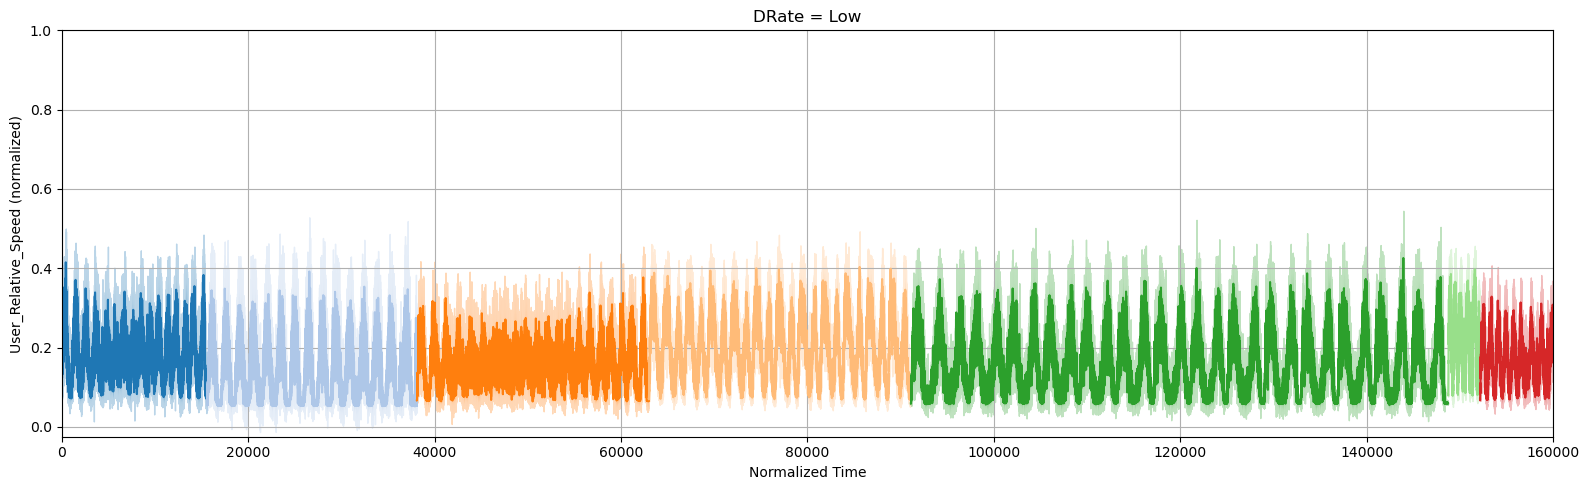

In [55]:
plot_segmented(df_by_approach_low, DRate='Low', column='User_Relative_Speed', normalize=True, group_col='AGV_Approaching', ax=None)

plt.xlim(0, 160000)
plt.ylim(-0.025, 1)

plt.tight_layout()
plt.show()

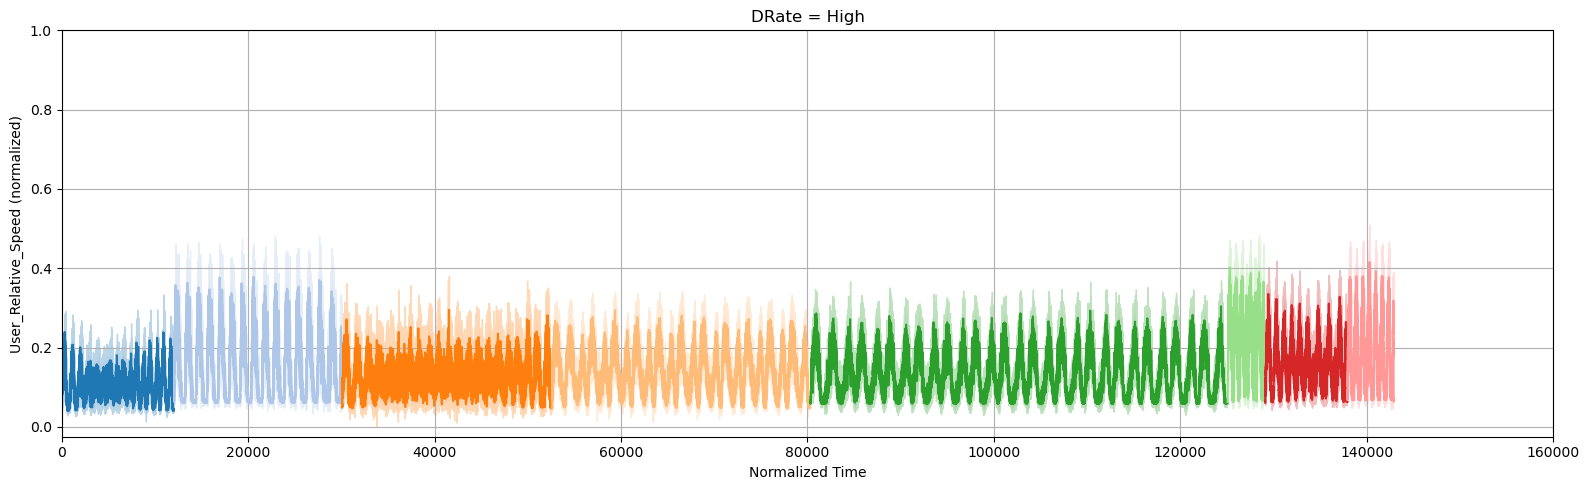

In [56]:
plot_segmented(df_by_approach_high, DRate='High', column='User_Relative_Speed', normalize=True, group_col='AGV_Approaching', ax=None)

plt.xlim(0, 160000)
plt.ylim(-0.025, 1)

plt.tight_layout()
plt.show()

### By User Trajectory

In [62]:
df_by_trajectory_low, _ = add_normalized_time(
    study_data_by_sec,
    column = 'User_Relative_Speed',
    smooth = True,
    DRate = 'Low',
    group_col = 'User_Trajectory'
)

In [63]:
df_by_trajectory_high, _ = add_normalized_time(
    study_data_by_sec,
    column = 'User_Relative_Speed',
    smooth = True,
    DRate = 'High',
    group_col = 'User_Trajectory'
)

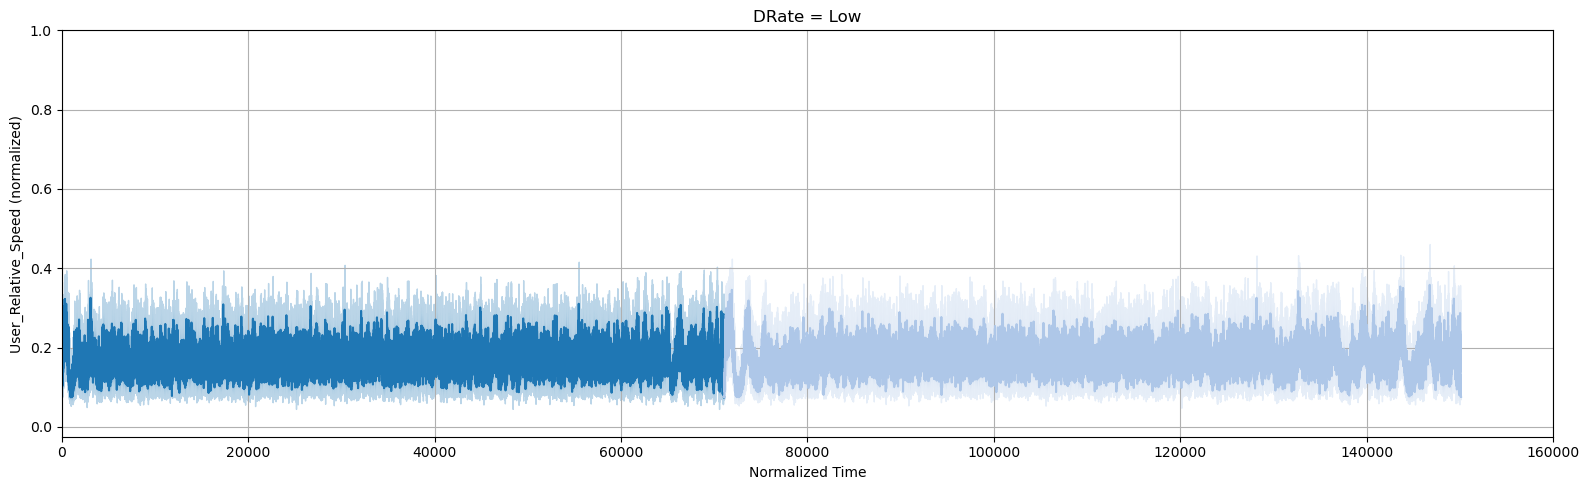

In [66]:
plot_segmented(df_by_trajectory_low, DRate='Low', column='User_Relative_Speed', normalize=True, group_col='User_Trajectory', ax=None)

plt.xlim(0, 160000)
plt.ylim(-0.025, 1)

plt.tight_layout()
plt.show()

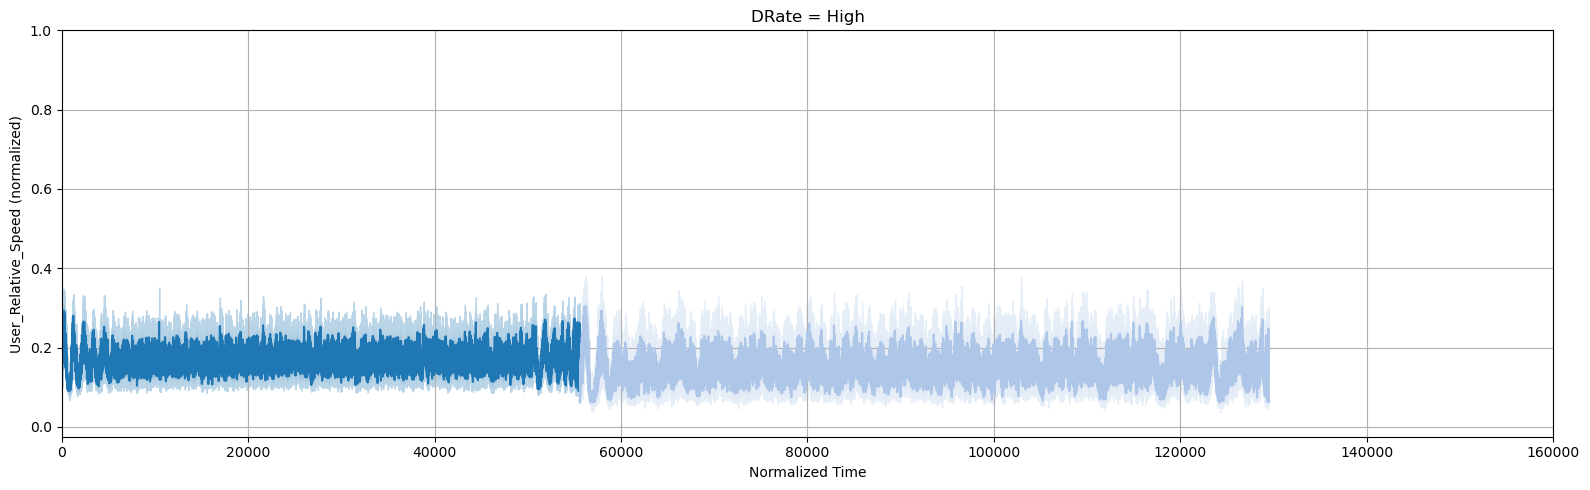

In [67]:
plot_segmented(df_by_trajectory_high, DRate='High', column='User_Relative_Speed', normalize=True, group_col='User_Trajectory', ax=None)

plt.xlim(0, 160000)
plt.ylim(-0.025, 1)

plt.tight_layout()
plt.show()